<h1 style="text-align:center; font-size:32px;">
Financial Fraud Detection Using Autoencoders
</h1>

<h3 style="text-align:center; font-weight:normal;">
Unsupervised Anomaly Detection in Financial Transactions
</h3>

The main objective of this project is to develop anomaly detection based on deep learning and to investigate whether such methods can identify atypical patterns in financial transactions.

First, an autoencoder will be trained on legitimate transactions to learn about the structure of what is considered the normal transaction behaviour. Afterwards, reconstruction error is considered as an anomaly score to identify transactions that deviate from said patterns.

This leads to an important question, 
##### do these anomalous behaviours provide relevant information for financial fraud monitoring?


Identifying fraudulent activities can seem as a difficult task due to the large volume of transactions made on a daily basis. Traditional detection of fraud tends to be based on pre-established fraud patterns. Nonetheless, an unusual transaction may not always follow these patterns. We are able to achieve a complementary approach by identifying observations which differ considerably from a "normal" behaviour.

To start with, autoencoder is trained to learn normal transaction behaviour with known observations. Following this, reconstruction error is used as a measuring tool to determine the difference between the original and the reconstructed transaction. 
When a transaction has a high reconstruction error it is considered an anomalous transaction. Different thresholds applied to this error to evaluate how useful anomaly detection can be for fraud tracking.

The following dataset is considered: "Credit Card Fraud Detection - Machine Learning Group, Université Libre de Bruxelles", showing a list of financial transaction and labelled as legit or fraudulent.

This dataset contains 284,807 transactions, 492 of which are frauds, showing a clearly highly unbalanced dataset; and 31 variables, which include transaction time, transaction amount, 28 anonymous numerical variables (V1-V28) and Class. Class is a binary variable which displays a 0 when the transaction is legitimate and 1 when it's fraudulent.(Although there are 28 anonymous variables, it can still be used by the model to identify patterns).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


The mean value of 0.001727 hows the strong unbalance of fraud observations.
The amount variable has a mean value of 88.35, median value of 22 and maximum value of 25,691.16, which sugests an asymetric distribution.

In [14]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [16]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

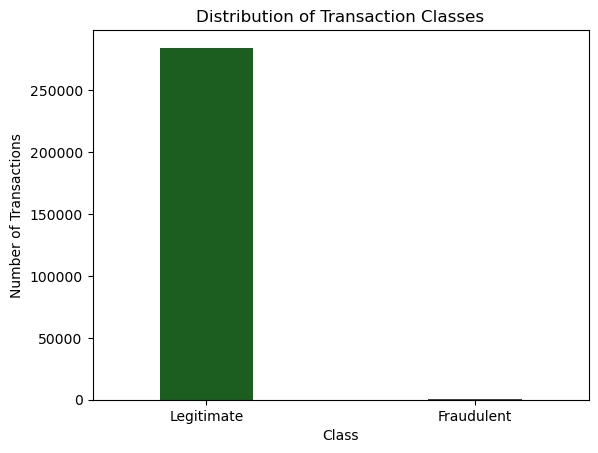

In [68]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(
    kind="bar",
    width=0.35,
    color="#1B5E20")

plt.title("Distribution of Transaction Classes")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"], rotation=0)
plt.show()

Once again, the normalized data shows how unbalanced the dataset is, where 99.8273% of the transactions are legitimate and only 0.1727% of theme are fraudulent. This is why accuracy will not a meaningful measure of performance, as a baseline model that classifies all transactions as legitimate would attain a 99.8273% success rate.

In [22]:
df["Hour"] = (df["Time"] // 3600) % 24

Variables present considerable differences on ranges --> feature scale
Standarisation will be accomplished since the model will rely on the reconstruction error

In [25]:
df.groupby("Hour")["Class"].mean() * 100

Hour
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64

A transformation of variable "Time" to an hourly variable becomes interesting for the project. Apparently, some hour periods show higher fraud rates, especially the 2-4am period. Nonetheless, we are working with too little fraudulent transactions to consider this as concluding.

In [28]:
df.groupby("Class")["Amount"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Class,,,,,
0,88.291022,22.00,250.105092,0.0,25691.16
1,122.211321,9.25,256.683288,0.0,2125.87


Also, transaction amounts also show interesting distributions. Fraudulent transactions have a higher mean but their median is lower. This suggests that fraudulent amounts are not characterized by higher transaction amounts. 

Time variable is transformed to be cyclical. This is needed to maintain constant time throughout hours of different days

In [33]:
df["Hour"] = (df["Time"] // 3600) % 24

df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

In [35]:
X = df.drop(columns=["Class"])
y = df["Class"]

X = X.drop(columns=["Time", "Hour"])

Fraudulent and legitimate transactions are separated, where X_normal will be used for the model to learn the "normal" pattern and X_fraud will be used to evaluate afterwards. X_fraud will not be used in the training part as we have chosen a non-supervised detection of anomalies.

In [39]:
X_normal = X[y == 0]
X_fraud = X[y == 1]

Only legitimate transactions are split into training, validation and testing sets.
Firstly, X_train -> 70% and X_temp -> 30%
Afterwards 50% is applied to X_temp, leaving the total as X_train -> 70%, X_val -> 15% and X_test -> 15%.

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_temp = train_test_split(
    X_normal,
    test_size=0.30,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42
)

As we mentioned earlier, data must be standarized, as extremely different numerical scales could affect the reconstruction error. This will be done using 

$$
z = \frac{x-\mu}{\sigma}
$$



In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_fraud_scaled = scaler.transform(X_fraud)

In [49]:
pd.DataFrame(X_train_scaled).describe().loc[["mean", "std"]]

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
mean,-2.961487e-17,-1.121045e-17,-1.237077e-17,3.998633e-18,4.712674e-18,-9.925177e-18,-1.292415e-17,4.998291e-18,-3.480953e-18,-1.249573e-17,...,-1.160318e-17,-5.319609e-18,1.106764e-17,3.141783e-17,-2.288503e-17,2.320635e-18,1.071062e-18,2.663375e-17,9.289680e-17,-4.394926e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00




For each transaction, represented by a feature vector $x \in \mathbb{R}^d$, the autoencoder learns two functions: an encoder $f_\theta$ that maps the input into a lower-dimensional latent representation, and a decoder $g_\phi$ that reconstructs the original input:

$$
z = f_\theta(x), \qquad \hat{x} = g_\phi(z)
$$

The model is trained to minimize the reconstruction error between the original transaction $x$ and the reconstruction $\hat{x}$ by using the mean squared error:

$$
L(x,\hat{x}) = \frac{1}{d}\sum_{j=1}^{d}(x_j-\hat{x}_j)^2
$$


The architecture will reduce the original 31 input variables to a reduced latent representation to reconstruct them afterwards.

As a starting point, I will use:
$$
\mathbb{R}^{31}
\rightarrow
\mathbb{R}^{16}
\rightarrow
\mathbb{R}^{8}
\rightarrow
\mathbb{R}^{16}
\rightarrow
\mathbb{R}^{31}
$$

In [55]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense

In [56]:
input_dim = X_train_scaled.shape[1]

inputs = Input(shape=(input_dim,))

encoder = Dense(16, activation="relu")(inputs)
encoder = Dense(8, activation="relu")(encoder)

decoder = Dense(16, activation="relu")(encoder)
outputs = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs, outputs)

In [57]:
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

Mean Squared Error (MSE)
$$
MSE(x,\hat{x}) =
\frac{1}{d}\sum_{j=1}^{d}(x_j-\hat{x}_j)^2
$$

to measure the diference between the original transaction and the reconstructed one.

Squaring the reconstruction errors makes the contribution of large deviations grow non-linearly. Validation loss is also monitored during the training part. This way we can study how well the model generalizes to legitimate transactions that were not included in the training set.

In [59]:
history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=50,
    batch_size=256,
    shuffle=True,
    verbose=1
)

Epoch 1/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8088 - val_loss: 0.6705
Epoch 2/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6031 - val_loss: 0.5764
Epoch 3/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5533 - val_loss: 0.5493
Epoch 4/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5306 - val_loss: 0.5335
Epoch 5/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5159 - val_loss: 0.5229
Epoch 6/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5068 - val_loss: 0.5170
Epoch 7/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4987 - val_loss: 0.5085
Epoch 8/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4925 - val_loss: 0.5046
Epoch 9/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4884 - val_loss: 0.5016
Epoch 10/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4851 - val_loss: 0.4994
Epoch 11/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4827 - val_loss: 0.4962
Epoch 12/50
778/778 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [8]:
#X_train_scaled

In [ ]:
######

In [ ]:
# IN PROGRESS

In [ ]:
######